Employee salary prediction is an important application of machine learning in the field of Human Resources (HR) and workforce analytics. Organizations use salary prediction models to estimate fair compensation based on factors such as years of experience, education level, job role, age, and other professional attributes. Accurate salary prediction helps companies maintain competitive pay structures, improve employee satisfaction, and support better recruitment and budgeting decisions.

In this notebook, we will use a medium-sized dataset containing real-world employee information and salary records. By analyzing features such as experience, education, age, and job-related characteristics, we will develop a machine learning model capable of predicting employee salaries with high accuracy.

By analyzing this dataset, we aim to build a predictive model that can estimate employee salaries efficiently, assist HR professionals in making data-driven compensation decisions, and provide valuable insights into the factors that influence employee earnings.

In [49]:
# ==============================
# Data Manipulation
# ==============================
import numpy as np
import pandas as pd

# ==============================
# Data Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Machine Learning
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor


# ==============================
# Model Evaluation
# ==============================
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==============================
# Model Saving
# ==============================
import joblib

# ==============================
# Ignore Warnings
# ==============================
import warnings
warnings.filterwarnings("ignore")

# ==============================
# Plot Settings
# ==============================
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


DATA PROSSESING

In [50]:
df = pd.read_csv("C:/Users/S.store/OneDrive/Desktop/zeiad project/Salary Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 30.8 KB


In [52]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [53]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [54]:
df.isnull()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
370,False,False,False,False,False,False
371,False,False,False,False,False,False
372,False,False,False,False,False,False
373,False,False,False,False,False,False


In [55]:
df.dropna()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [56]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 375
Number of Columns: 6


In [57]:
df.dtypes

Age                    float64
Gender                     str
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
dtype: object

In [58]:
# Duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 50


EDA

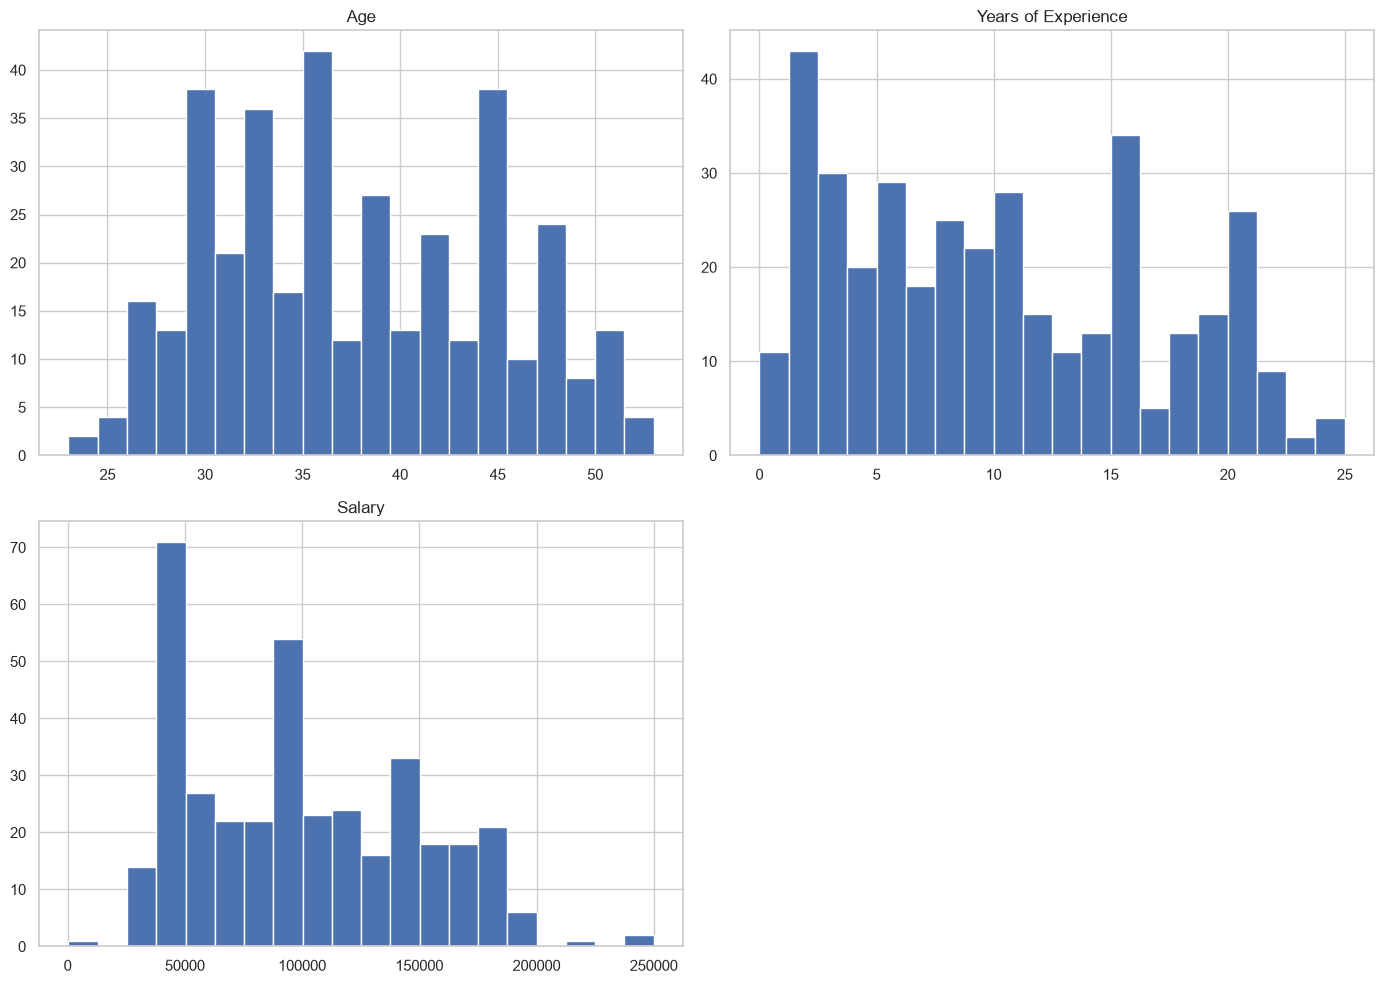

In [59]:
df.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

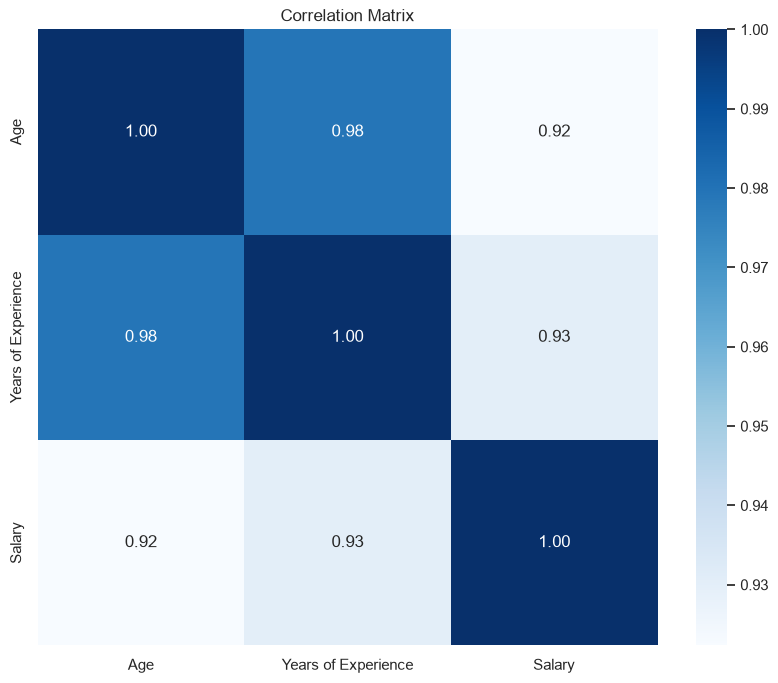

In [60]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

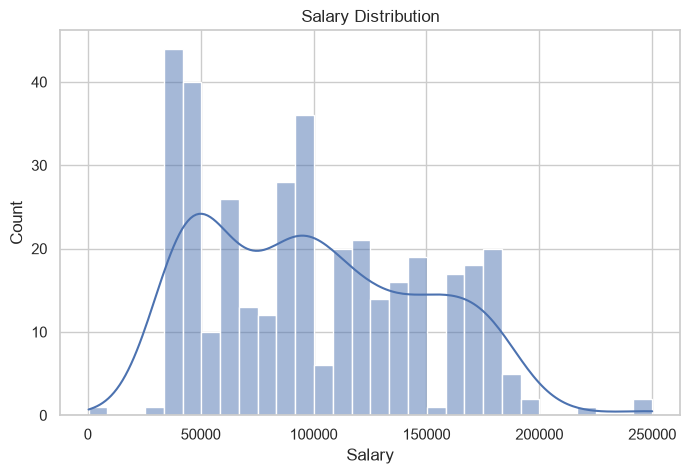

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df["Salary"], bins=30, kde=True)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Count")

plt.show()

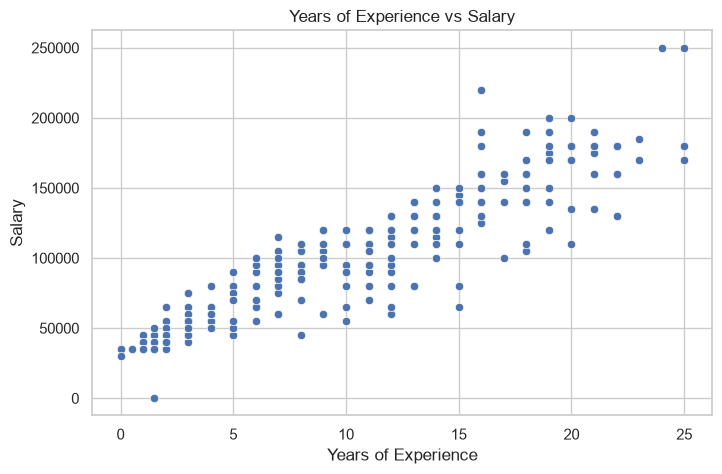

In [62]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Years of Experience", y="Salary")

plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

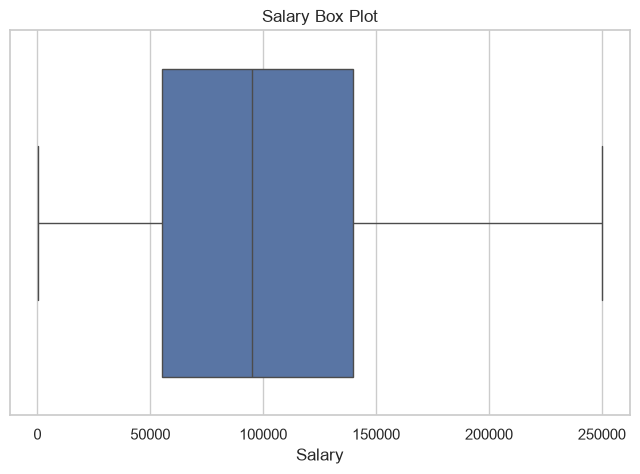

In [63]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Salary"])

plt.title("Salary Box Plot")
plt.show()

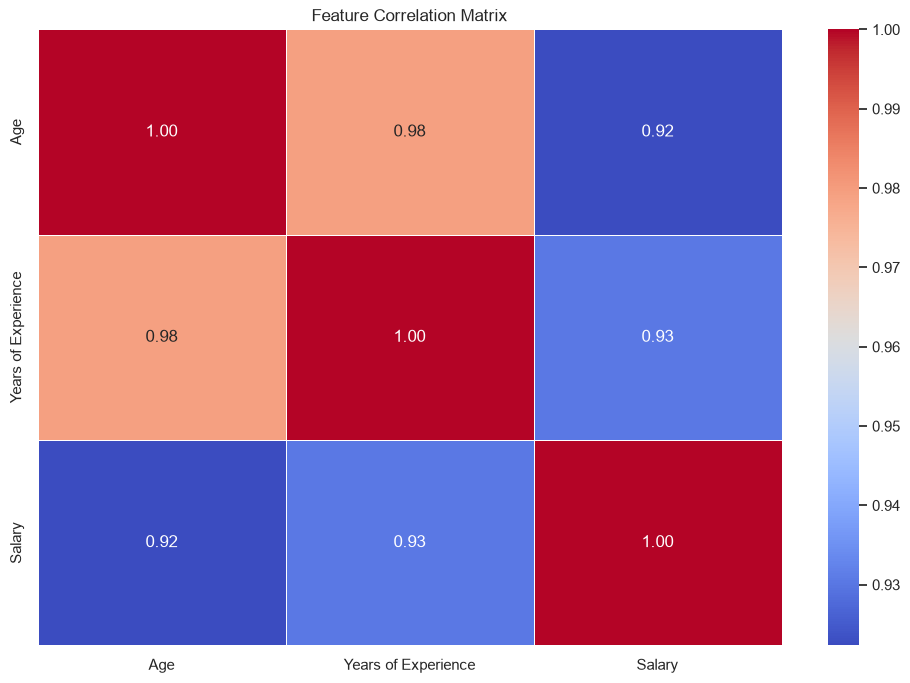

In [64]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

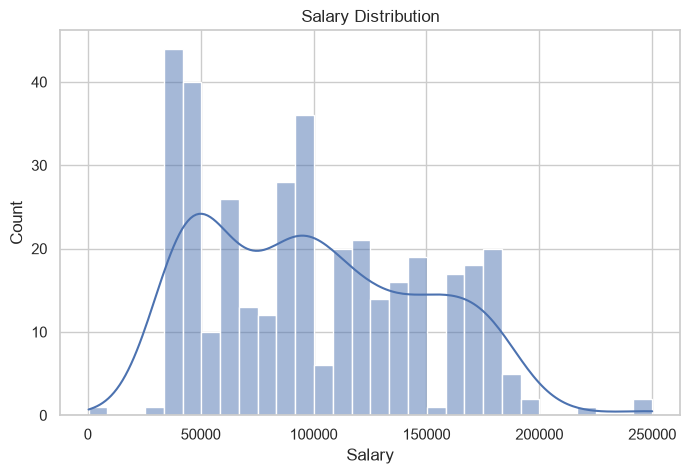

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Salary"],
    kde=True,
    bins=30
)

plt.title("Salary Distribution")
plt.show()

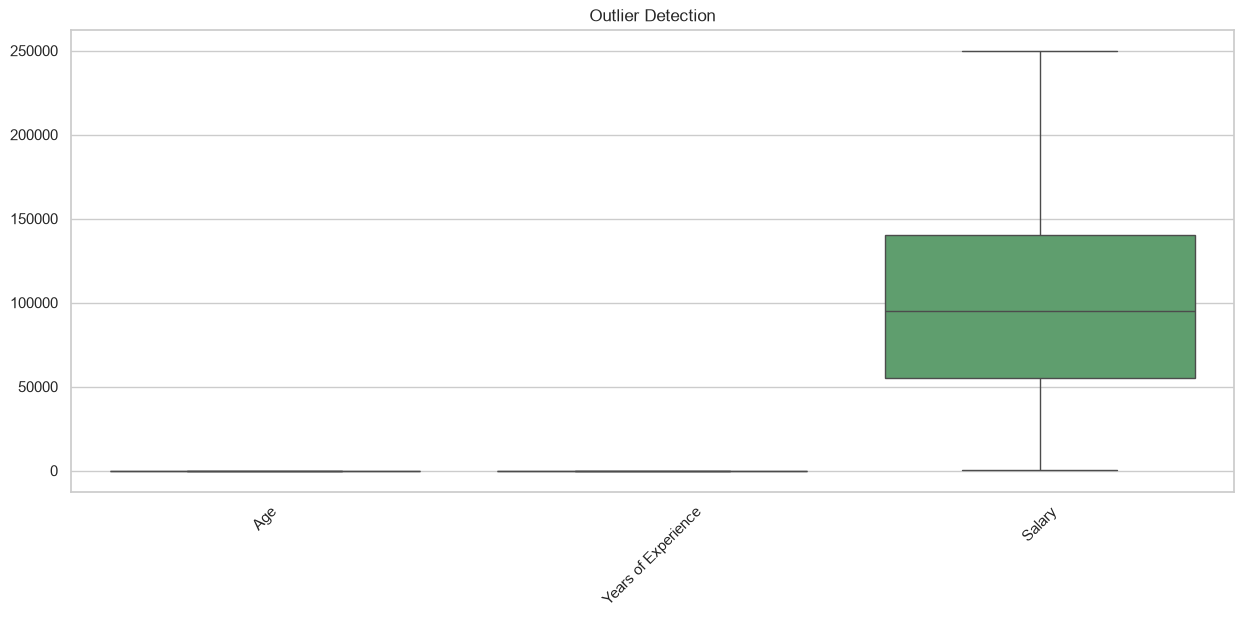

In [66]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,6))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)

plt.title("Outlier Detection")

plt.show()

Model Training

In [67]:
# ===============================
# Data Preprocessing
# ===============================

# Check missing values
print(df.isnull().sum())

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Split Features and Target
X = df.drop("Salary", axis=1)
y = df["Salary"]

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [68]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col])

X.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,159,5.0
1,28.0,0,1,17,3.0
2,45.0,1,2,130,15.0
3,36.0,0,0,101,7.0
4,52.0,1,1,22,20.0


In [69]:
df.dropna(inplace=True)

In [70]:
X = df.drop("Salary", axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (259, 5)
Testing Set : (65, 5)


In [72]:
print(X.select_dtypes(include="object").columns)

Index(['Gender', 'Education Level', 'Job Title'], dtype='str')


In [73]:
from sklearn.preprocessing import LabelEncoder

X = X.copy()

for col in X.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    X[col] = encoder.fit_transform(X[col].astype(str))

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (259, 5)
X_test Shape : (65, 5)
y_train Shape: (259,)
y_test Shape : (65,)


In [78]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='str')

Train Linear Regression

In [79]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


Predict using Linear Regression

In [80]:
# Make predictions
lr_pred = lr_model.predict(X_test)

# Display first 10 predictions
comparison_lr = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": lr_pred
})

comparison_lr.head(10)

,Actual Salary,Predicted Salary
0,100000.0,117415.913446
1,100000.0,125562.807428
2,50000.0,48965.153862
3,110000.0,128739.348880
4,105000.0,106828.499305
5,95000.0,99654.767488
6,45000.0,49101.278837
7,55000.0,57130.711081
8,180000.0,166333.690093
9,40000.0,43112.610601


Evaluate Linear Regression

In [81]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("-"*35)
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)
print("Accuracy:", lr_r2*100,"%")

Linear Regression Results
-----------------------------------
MAE : 10570.78640113619
MSE : 205754135.71726152
RMSE: 14344.132449097837
R² Score: 0.8911231066517087
Accuracy: 89.11231066517087 %


Train Random Forest

In [82]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


Predict using Random Forest

In [83]:
rf_pred = rf_model.predict(X_test)

comparison_rf = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": rf_pred
})

comparison_rf.head(10)

,Actual Salary,Predicted Salary
0,100000.0,106800.0
1,100000.0,118875.0
2,50000.0,48500.0
3,110000.0,115000.0
4,105000.0,103275.0
5,95000.0,100700.0
6,45000.0,50300.0
7,55000.0,54750.0
8,180000.0,172250.0
9,40000.0,46425.0


Evaluate Random Forest

In [84]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("-"*35)
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)
print("Accuracy:", rf_r2*100,"%")

Random Forest Results
-----------------------------------
MAE : 9315.802243589742
MSE : 163411302.59487844
RMSE: 12783.243039028806
R² Score: 0.9135292474073204
Accuracy: 91.35292474073205 %


Compare Models

In [85]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "MSE": [lr_mse, rf_mse],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2],
    "Accuracy (%)": [lr_r2*100, rf_r2*100]
})

results.sort_values(by="Accuracy (%)", ascending=False)

,Model,MAE,MSE,RMSE,R² Score,Accuracy (%)
1,Random Forest,9315.802244,1.634113e+08,12783.243039,0.913529,91.352925
0,Linear Regression,10570.786401,2.057541e+08,14344.132449,0.891123,89.112311


Visualization

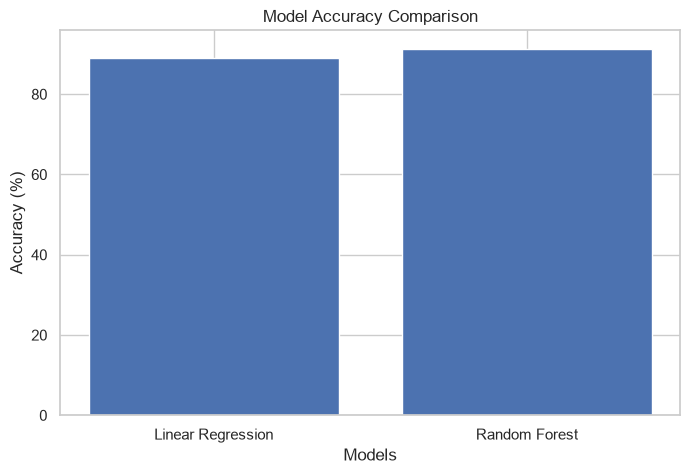

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy (%)"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.show()

In [87]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [88]:
import joblib

joblib.dump(rf_model, "employee_salary_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [89]:
joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [90]:
from sklearn.preprocessing import LabelEncoder

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [91]:
import joblib

joblib.dump(encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [ ]:
!streamlit run app.py